# Part 2: Demand Estimation

We estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}
$$

Where:
- $b$ indexes brands, $t$ indexes years
- $s_{bt}$ is `brand_share`, $p_{bt}$ is `avg_price`, $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristic shares
- $\alpha_t$ are year fixed effects, $\gamma_b$ are brand fixed effects
- $\beta_{price}$ is **one constant price coefficient** shared by all brands and years

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
print(df.shape)
df.head()

(50, 15)


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


## Setting Up the Regression

In [12]:
# Outcome variable
y = df['log_brand_share']

# Product characteristic features
feature_cols = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']

# drop_first=True drops 'chefman' and '2019' as reference categories
# all other dummy coefficients are interpreted relative to these
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True, dtype=int)

# Full feature matrix
# concat price/rating, product features, and dummies into one feature matrix
# we do NOT estimate separate price coefficients per brand — one shared beta_price only
X = pd.concat(
    [df[['avg_price', 'avg_rating'] + feature_cols],
     brand_dummies,
     year_dummies],
    axis=1
)

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (50, 20)


,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,brand_cosori,brand_cuisinart,brand_dash,brand_gowise usa,brand_instant_pot,brand_ninja,brand_nuwave,brand_oster,brand_ultrean,year_2020,year_2021,year_2022,year_2023
0,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,0,0,0,0,0,0,0,0,0,0,0,0,0
1,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,1,0,0,0,0,0,0,0,0,0,0,0,0
2,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,0,1,0,0,0,0,0,0,0,0,0,0,0
3,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,0,0,1,0,0,0,0,0,0,0,0,0,0
4,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,0,0,0,1,0,0,0,0,0,0,0,0,0


## Running the Regression

In [5]:
model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).round(4)

print(f"Intercept: {model.intercept_:.4f}")
print(f"R-squared: {r2:.4f}")
coef_table

Intercept: -13.3049
R-squared: 0.7635


,feature,coefficient
0,avg_price,-0.0377
1,avg_rating,0.2875
2,compact_share,9.8153
3,dual_basket_share,-9.5097
4,oven_style_share,1.9418
5,rotisserie_share,-5.6741
6,window_share,12.8803
7,brand_cosori,2.5519
8,brand_cuisinart,6.4224
9,brand_dash,0.1767


## Question 1 & 2: Price Coefficient

In [11]:
# sanity check — price coefficient must be negative for Part 3 to make sense
price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
print(f"Estimated price coefficient: {price_coef}")

Estimated price coefficient: -0.0377


**Q1: What is the estimated price coefficient?**

The estimated price coefficient is **-0.0377**.

**Q2: Is it negative? Why does that matter?**

Yes, the price coefficient is negative, which is exactly what economic theory predicts. A negative price coefficient means that higher prices are associated with lower log market share — consumers are less likely to choose a brand as its price increases, all else equal. This is the law of demand. If the coefficient were positive, the model would be implying that higher prices increase demand, which would make the cost and markup calculations in Part 3 economically meaningless. A negative price coefficient is a necessary sanity check before proceeding.

## Question 3: Product Feature Coefficients

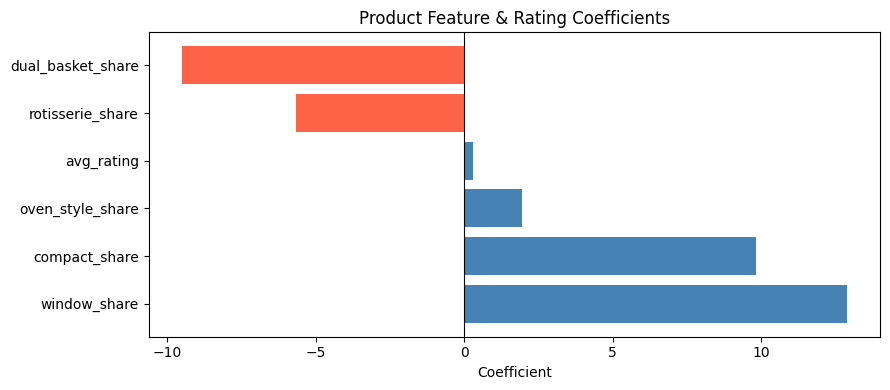

In [13]:
feature_coefs = coef_table[coef_table['feature'].isin(feature_cols + ['avg_rating'])].copy()
feature_coefs = feature_coefs.sort_values('coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
# blue = positive effect on demand, red = negative effect
colors = ['steelblue' if c > 0 else 'tomato' for c in feature_coefs['coefficient']]
ax.barh(feature_coefs['feature'], feature_coefs['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Product Feature & Rating Coefficients')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

Note: negative coefficients on dual basket and rotisserie reflect that these features are concentrated in lower-share brands, not necessarily that consumers dislike them.

**Q3: Which product features are associated with higher demand?**

The features with positive coefficients — meaning they are associated with **higher** log market share — are:
- **window_share** (12.88): the strongest positive feature by far
- **compact_share** (9.82): very strong positive effect
- **oven_style_share** (1.94): moderate positive effect
- **avg_rating** (0.29): higher ratings positively predict share

Features with **negative** coefficients (associated with lower demand):
- **dual_basket_share** (-9.51): strongly negative
- **rotisserie_share** (-5.67): strongly negative

The large negative coefficients on dual basket and rotisserie likely reflect that these are niche features concentrated in brands with lower overall shares, rather than that consumers dislike these features per se. The compact and window features are associated with the higher-share brands.

## Question 4: Brand Dummy Coefficients

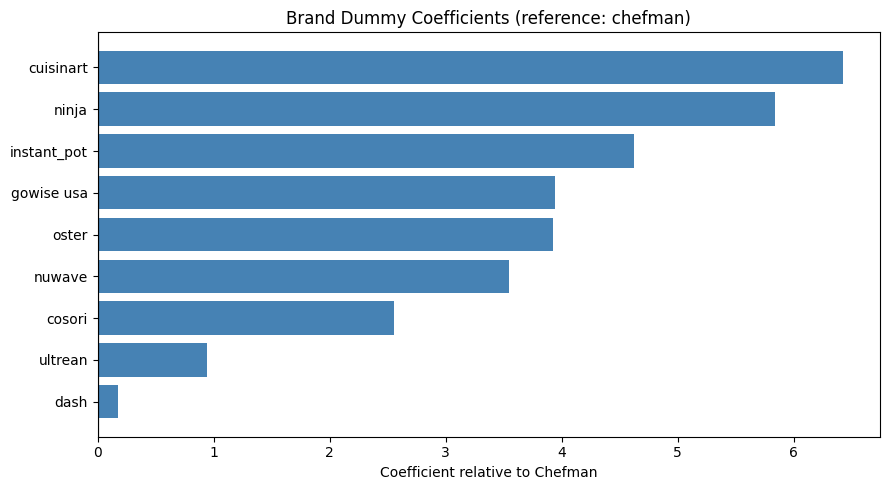

In [14]:
# reference brand is chefman (dropped by drop_first=True)
# all coefficients show how much higher/lower log share is vs chefman
brand_coefs = coef_table[coef_table['feature'].str.startswith('brand_')].copy()
brand_coefs['brand'] = brand_coefs['feature'].str.replace('brand_', '')
brand_coefs = brand_coefs.sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(brand_coefs['brand'], brand_coefs['coefficient'], color='steelblue')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Brand Dummy Coefficients (reference: chefman)')
ax.set_xlabel('Coefficient relative to Chefman')
plt.tight_layout()
plt.show()

**Q4: Which brand dummy coefficients are largest?**

The reference (dropped) brand is **Chefman**. All brand coefficients are interpreted relative to Chefman, holding price, rating, and product features constant.

The largest brand coefficients are:
- **Cuisinart** (6.42): highest brand fixed effect relative to Chefman
- **Ninja** (5.84): second highest
- **Instant Pot** (4.63): third highest

This means that after controlling for price, ratings, and product features, these brands have substantially higher predicted log market shares than Chefman. This likely reflects brand equity — consumers prefer these brands beyond what their observable characteristics explain. Dash (0.18) and Ultrean (0.94) have the smallest brand effects, meaning they perform similarly to Chefman once other factors are controlled for.

## Question 5: Year Dummy Coefficients

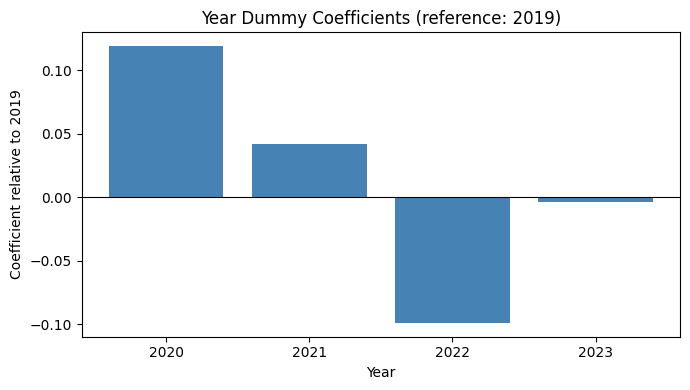

In [9]:
year_coefs = coef_table[coef_table['feature'].str.startswith('year_')].copy()
year_coefs['year'] = year_coefs['feature'].str.replace('year_', '')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(year_coefs['year'], year_coefs['coefficient'], color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year Dummy Coefficients (reference: 2019)')
ax.set_ylabel('Coefficient relative to 2019')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

**Q5: Which year dummy coefficients are largest?**

The reference (dropped) year is **2019**. All year coefficients are interpreted relative to 2019.

- **2020** (0.12): the largest positive year effect — the market expanded slightly relative to 2019, likely reflecting COVID-era increased home cooking
- **2021** (0.04): small positive effect
- **2023** (-0.003): essentially flat relative to 2019
- **2022** (-0.10): the most negative year effect, suggesting relative contraction

Overall, the year effects are small in magnitude compared to the brand and feature effects, suggesting that year-to-year market-level shifts are modest relative to cross-brand differences.

## Question 6: Model R-squared

Model R-squared: 0.7635


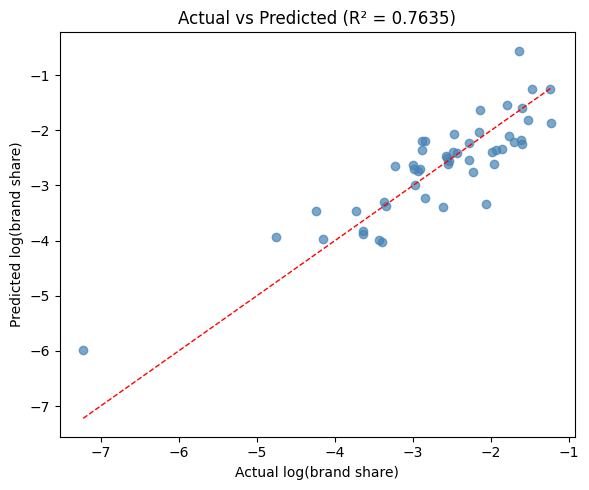

In [15]:
print(f"Model R-squared: {r2:.4f}")

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y, predicted_log_share, alpha=0.7, color='steelblue')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1)
ax.set_xlabel('Actual log(brand share)')
ax.set_ylabel('Predicted log(brand share)')
ax.set_title(f'Actual vs Predicted (R² = {r2:.4f})')
# red dashed line = perfect prediction
# points close to the line = model fits well
plt.tight_layout()
plt.show()

**Q6: What is the model's R-squared?**

The model's R-squared is **0.7635**, meaning the model explains approximately 76% of the variation in log brand market share. This is a strong fit for a cross-sectional demand model with only 50 observations. The brand and year fixed effects do most of the heavy lifting — they absorb persistent differences in brand popularity and market-wide year effects. The remaining variation explained by price, ratings, and product features reflects how observable characteristics shift demand within brands over time.